![MuJoCo banner](https://raw.githubusercontent.com/google-deepmind/mujoco/main/banner.png)







### Copyright notice

> <p><small><small>Copyright 2025 DeepMind Technologies Limited.</small></p>
> <p><small><small>Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at <a href="http://www.apache.org/licenses/LICENSE-2.0">http://www.apache.org/licenses/LICENSE-2.0</a>.</small></small></p>
> <p><small><small>Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.</small></small></p>

# Manipulation in The Playground! <a href="https://colab.research.google.com/github/google-deepmind/mujoco_playground/blob/main/learning/notebooks/manipulation.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" width="140" align="center"/></a>

In this notebook, we'll walk through a couple manipulation environments available in MuJoCo Playground.

**A Colab runtime with GPU acceleration is required.** If you're using a CPU-only runtime, you can switch using the menu "Runtime > Change runtime type".


In [1]:
# # #@title Install pre-requisites
!pip install mujoco
!pip install mujoco_mjx
!pip install brax

# !pip install --break-system-packages mediapy -q

In [2]:
!pip install mediapy

In [3]:
# @title Check if MuJoCo installation was successful

import distutils.util
import os
import subprocess

if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU. '
      'Make sure you are using a GPU Colab runtime. '
      'Go to the Runtime menu and select Choose runtime type.'
  )

# Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
# This is usually installed as part of an Nvidia driver package, but the Colab
# kernel doesn't install its driver via APT, and as a result the ICD is missing.
# (https://github.com/NVIDIA/libglvnd/blob/master/src/EGL/icd_enumeration.md)
NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
  with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
    f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")

# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

try:
  print('Checking that the installation succeeded:')
  import mujoco

  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".'
  )

print('Installation successful.')

# Tell XLA to use Triton GEMM, this improves steps/sec by ~30% on some GPUs
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags

Wed Apr  1 15:32:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        Off |   00000000:02:00.0  On |                  Off |
| 30%   32C    P3             38W /  450W |     633MiB /  24564MiB |      8%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

/tmp/ipykernel_208293/1100621786.py:3: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils.util


In [4]:
# @title Import packages for plotting and creating graphics
import json
import itertools
import time
from typing import Callable, List, NamedTuple, Optional, Union
import numpy as np

# Graphics and plotting.
# print("Installing mediapy:")
# !command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
# !pip install -q mediapy
import mediapy as media
import matplotlib.pyplot as plt

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

In [5]:
# @title Import MuJoCo, MJX, and Brax
from datetime import datetime
import functools
import os
from typing import Any, Dict, Sequence, Tuple, Union
from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.io import html, mjcf, model
from brax.mjx.base import State as MjxState
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from brax.training.agents.sac import networks as sac_networks
from brax.training.agents.sac import train as sac
from etils import epath
from flax import struct
from flax.training import orbax_utils
from IPython.display import HTML, clear_output
import jax
from jax import numpy as jp
from matplotlib import pyplot as plt
import mediapy as media
from ml_collections import config_dict
import mujoco
from mujoco import mjx
import numpy as np
from orbax import checkpoint as ocp

In [6]:
#@title Install MuJoCo Playground
# !pip install playground

In [7]:
#@title Import The Playground

from mujoco_playground import wrapper
from mujoco_playground import registry
from mujoco_playground import registry

In [8]:
print(registry.__file__)

/home/aks-lab/mujoco_playground/mujoco_playground/_src/registry.py


# Manipulation

MuJoCo Playground contains several manipulation environments (all listed below after running the command).

In [9]:
registry.manipulation.ALL_ENVS

('AlohaHandOver',
 'AlohaSinglePegInsertion',
 'PandaPickCube',
 'PandaPickCubeOrientation',
 'PandaPickCubeCartesian',
 'PandaOpenCabinet',
 'PandaRobotiqPushCube',
 'LeapCubeReorient',
 'LeapCubeRotateZAxis',
 'DualUR5eBoxlift')

# Franka Emika Panda

Let's start off with the simplest environment, simply picking up a cube with the Franka Emika Panda.

In [10]:
# env_name = 'PandaPickCubeOrientation'
# env = registry.load(env_name)
# env_cfg = registry.get_default_config(env_name)

In [11]:
env_name = 'DualUR5eBoxlift'
env = registry.load(env_name)
env_cfg = registry.get_default_config(env_name)

INIT NOISE [0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3]


/home/aks-lab/mujoco_playground_venv/lib/python3.10/site-packages/jax/_src/interpreters/xla.py:119: RuntimeWarning: overflow encountered in cast
  return np.asarray(x, dtypes.canonicalize_dtype(x.dtype))
2026-04-01 15:32:28.133045: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


(158,)
(12, 158)

 Default backend: gpu
 Timestep: 0.1 
 CEM Iter: 2 
 Projection Iter: 5 
 Number of batches: 100 
 Number of steps per trajectory: 12 
 Time per trajectory: 1.2000000000000002 
 Number of variables: 144 
 Number of Total constraints: 1080 
 Number of geomteric IDs for colllision: 24


2026-04-01 15:32:44.265235: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


In [12]:
env_cfg
env_cfg.sim_dt

0.1

## Train Policy

Let's train the pick cube policy and visualize rollouts. The policy takes roughly 3 minutes to train on an RTX 4090.

In [13]:
from mujoco_playground.config import manipulation_params
ppo_params = manipulation_params.brax_ppo_config(env_name)
ppo_params

action_repeat: 1
batch_size: 256
discounting: 0.99
entropy_cost: 0.01
episode_length: 50
learning_rate: 0.0001
network_factory:
  policy_hidden_layer_sizes: &id001 !!python/tuple
  - 512
  - 256
  - 128
  policy_obs_key: state
  value_hidden_layer_sizes: *id001
  value_obs_key: privileged_state
normalize_observations: true
num_envs: 256
num_evals: 10
num_minibatches: 32
num_resets_per_eval: 1
num_timesteps: 1000000
num_updates_per_batch: 2
reward_scaling: 1.0
unroll_length: 20

In [14]:
from mujoco_playground.config import manipulation_params
ppo_params = manipulation_params.brax_ppo_config(env_name)

# # Remove asymmetric observation keys since this env uses flat obs
# if "policy_obs_key" in ppo_params:
#     del ppo_params["policy_obs_key"]
# if "value_obs_key" in ppo_params:
#     del ppo_params["value_obs_key"]

print("Updated ppo_params - removed obs keys")
print(f"policy_obs_key: {ppo_params.get('policy_obs_key')}")
print(f"value_obs_key: {ppo_params.get('value_obs_key')}")

Updated ppo_params - removed obs keys
policy_obs_key: None
value_obs_key: None


In [21]:


# 🔍 DEBUG HERE (before training)
rng = jax.random.PRNGKey(0)
state = env.reset(rng)
data = state.data

print("qpos:", data.qpos.shape, data.qpos.size)
print("qvel:", data.qvel.shape, data.qvel.size)

# target_id = env._mj_model.body_mocapid[
#     env._mj_model.body(name='target_0').id
# ]

# print("target_id:", target_id)
print("mocap_pos:", data.mocap_pos.shape)

print("OBS: state", state.obs['state'].shape)
print("OBS: privileged state", state.obs['privileged_state'].shape)


qpos: (19,) 19
qvel: (18,) 18
mocap_pos: (2, 3)
OBS: state (45,)
OBS: privileged state (45,)


In [22]:


x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]


def progress(num_steps, metrics):
  clear_output(wait=True)

  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")

  display(plt.gcf())

ppo_training_params = dict(ppo_params)
network_factory = ppo_networks.make_ppo_networks
if "network_factory" in ppo_params:
  del ppo_training_params["network_factory"]
  network_factory_kwargs = dict(ppo_params.network_factory)
  # Remove asymmetric obs keys — DualUR5eBoxlift returns flat obs, not a dict
  network_factory_kwargs.pop("policy_obs_key", None)
  network_factory_kwargs.pop("value_obs_key", None)
  network_factory = functools.partial(
      ppo_networks.make_ppo_networks,
      **network_factory_kwargs
  )

train_fn = functools.partial(
    ppo.train, **dict(ppo_training_params),
    network_factory=network_factory,
    progress_fn=progress,
    seed=1
)


In [ ]:
# # Diagnostic: intercept network_factory to see what ppo.train passes
# _original_nf = network_factory
# def debug_network_factory(obs_size, action_size, **kwargs):
#     print(f"[DEBUG] network_factory called with:")
#     print(f"  obs_size = {obs_size} (type={type(obs_size)})")
#     print(f"  action_size = {action_size}")
#     print(f"  kwargs keys = {list(kwargs.keys())}")
#     return _original_nf(obs_size, action_size, **kwargs)

# # Temporarily replace network_factory in train_fn
# import copy
# train_fn_debug = functools.partial(
#     ppo.train,
#     **{k: v for k, v in ppo_training_params.items()},
#     network_factory=debug_network_factory,
#     progress_fn=progress,
#     seed=1,
# )
# make_inference_fn, params, metrics = train_fn_debug(
#     environment=env,
#     wrap_env_fn=wrapper.wrap_for_brax_training,
# )


### PPO

In [24]:
print("\n" + "=" * 50)
print(state.obs['state'])
print("\n" + "=" * 50)
print(state.obs['privileged_state'])


[ 1.204 -2.087  1.799 -1.333 -1.766 -0.228 -1.725 -1.73   1.507 -0.96  -1.645  0.199 -0.29   0.01
  0.35   1.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.    -0.34  -0.116  0.313  0.997  0.
  0.    -0.073  0.   ]

[ 1.204 -2.087  1.799 -1.333 -1.766 -0.228 -1.725 -1.73   1.507 -0.96  -1.645  0.199 -0.29   0.01
  0.35   1.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.    -0.34  -0.116  0.313  0.997  0.
  0.    -0.073  0.   ]


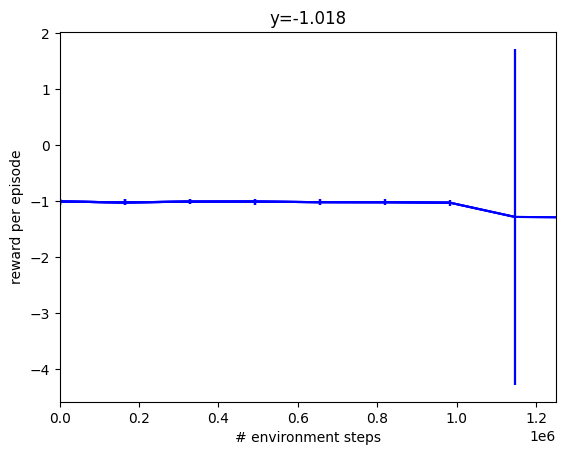

time to jit: 0:03:12.739144
time to train: 1:45:11.150384


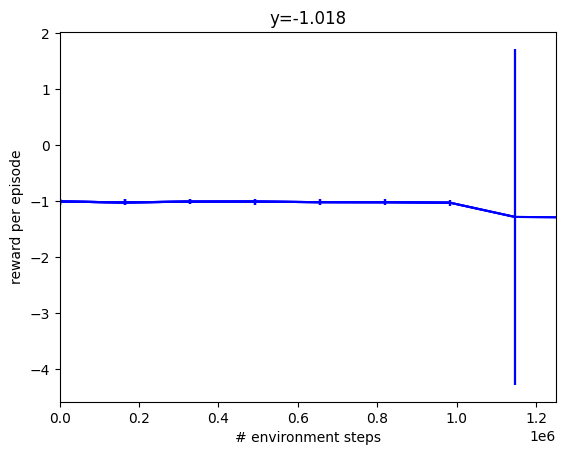

In [25]:
make_inference_fn, params, metrics = train_fn(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,
)
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")


In [68]:
import orbax.checkpoint as ocp
import os

# Define a checkpoint manager
checkpoint_dir = os.path.abspath('./checkpoints')
manager = ocp.CheckpointManager(
    checkpoint_dir, # Directory to save checkpoints
    options=ocp.CheckpointManagerOptions(
        save_interval_steps=1, # Save every step (useful for debugging, adjust for production)
        max_to_keep=1 # Keep only the latest checkpoint
    )
)

# Save the trained parameters
step = 0 # Or any meaningful step number, e.g., final_step
args = ocp.args.StandardSave(params)
manager.save(step, args=args)

print(f"Trained parameters saved to: {manager.directory}/checkpoint_{step}")

Trained parameters saved to: /home/aks-lab/mujoco_playground/learning/notebooks/checkpoints/checkpoint_0


In [69]:
import orbax.checkpoint as ocp
import os

# Re-initialize the checkpoint manager, pointing to the same directory
checkpoint_dir = os.path.abspath('./checkpoints')
manager = ocp.CheckpointManager(
    checkpoint_dir,
    options=ocp.CheckpointManagerOptions(max_to_keep=1)
)

# Load the latest checkpoint
# Replace '0' with the actual step number if you saved multiple checkpoints
# restored_params = manager.restore(0)
restored_params = manager.restore(0, args=ocp.args.StandardRestore(params))

print("Parameters loaded successfully.")
# You can now use restored_params with make_inference_fn
# e.g., jit_inference_fn_loaded = jax.jit(make_inference_fn(restored_params, deterministic=True))

Parameters loaded successfully.


## Visualize Rollouts

In [70]:
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)
# jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))
jit_inference_fn = jax.jit(make_inference_fn(restored_params, deterministic=True))

In [ ]:
!apt install -y ffmpeg

In [77]:
rng = jax.random.PRNGKey(42)
rollout = []
n_episodes = 5

for _ in range(n_episodes):
  state = jit_reset(rng)
  rollout.append(state)
  for i in range(env_cfg.episode_length):
    act_rng, rng = jax.random.split(rng)
    ctrl, _ = jit_inference_fn(state.obs, act_rng)
    state = jit_step(state, ctrl)
    rollout.append(state)

render_every = 1
frames = env.render(rollout[::render_every])
rewards = [s.reward for s in rollout]
media.show_video(frames, fps=1.0 / env.dt / render_every)

100%|██████████| 255/255 [00:00<00:00, 576.89it/s]


This browser does not support the video tag.


In [78]:
# Extract from the rollout list
qpos = jp.stack([s.data.qpos for s in rollout])   # (T, nq)
qvel = jp.stack([s.data.qvel for s in rollout])   # (T, nv)
ctrl = jp.stack([s.data.ctrl for s in rollout])    # (T, nu)
rewards = jp.stack([s.reward for s in rollout])    # (T,)

print("qpos shape:", qpos.shape)

qpos shape: (255, 19)


In [79]:
# rewards = jp.stack([s.reward for s in rollout])    # (T,)


# --- State-level fields ---
rewards = jp.stack([s.reward for s in rollout])          # (T,)
dones = jp.stack([s.done for s in rollout])              # (T,)
obs_all = jp.stack([s.obs['state'] for s in rollout])             # (T, obs_dim)

# --- MJX Data fields (physics state) ---
qpos = jp.stack([s.data.qpos for s in rollout])          # (T, nq) - joint positions
qvel = jp.stack([s.data.qvel for s in rollout])          # (T, nv) - joint velocities
ctrl = jp.stack([s.data.ctrl for s in rollout])           # (T, nu) - applied controls
xpos = jp.stack([s.data.xpos for s in rollout])          # (T, nbody, 3) - body positions
xquat = jp.stack([s.data.xquat for s in rollout])        # (T, nbody, 4) - body orientations
site_xpos = jp.stack([s.data.site_xpos for s in rollout])  # (T, nsite, 3) - site positions
mocap_pos = jp.stack([s.data.mocap_pos for s in rollout])   # (T, nmocap, 3) - mocap positions
mocap_quat = jp.stack([s.data.mocap_quat for s in rollout]) # (T, nmocap, 4) - mocap orientations
qfrc_actuator = jp.stack([s.data.qfrc_actuator for s in rollout])  # (T, nv) - actuator forces
sensordata = jp.stack([s.data.sensordata for s in rollout])  # (T, nsensor) - sensor readings
xfrc_applied = jp.stack([s.data.xfrc_applied for s in rollout])  # (T, nbody, 6) - applied forces

# --- Info dict (env-specific) ---
steps = jp.stack([s.info['_steps'] for s in rollout])    # (T,)

print(f"Rollout length: {len(rollout)}")
print(f"qpos: {qpos.shape}, qvel: {qvel.shape}, ctrl: {ctrl.shape}")
print(f"xpos: {xpos.shape}, xquat: {xquat.shape}")
print(f"sensordata: {sensordata.shape}")
print(f"mocap_pos: {mocap_pos.shape}")
print(f"mocap_quat: {mocap_quat.shape}")
print(f"rewards: {rewards.shape}, obs: {obs_all.shape}")

Rollout length: 255
qpos: (255, 19), qvel: (255, 18), ctrl: (255, 0)
xpos: (255, 42, 3), xquat: (255, 42, 4)
sensordata: (255, 0)
mocap_pos: (255, 2, 3)
mocap_quat: (255, 2, 4)
rewards: (255,), obs: (255, 45)


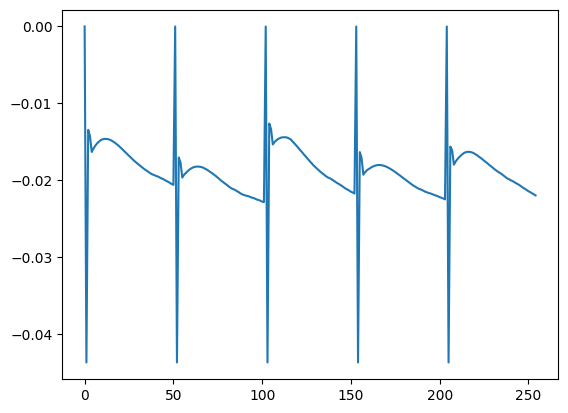

In [80]:
plt.plot(rewards)
plt.show()

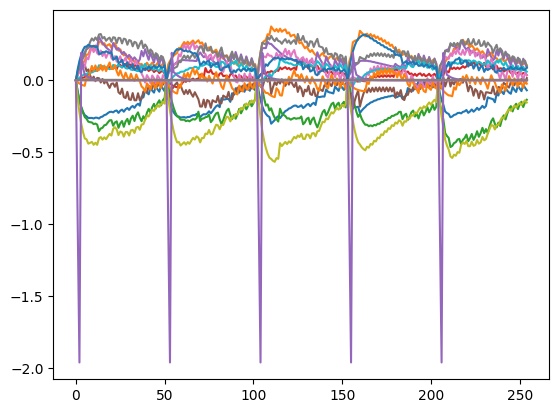

In [82]:

plt.plot(qvel)
plt.show()

While the above policy is very simple, the work was extended using the Madrona batch renderer, and policies were transferred on a real robot. We encourage folks to check out the Madrona-MJX tutorial notebooks ([part 1](https://colab.research.google.com/github/google-deepmind/mujoco_playground/blob/main/learning/notebooks/training_vision_1.ipynb) and [part 2](https://colab.research.google.com/github/google-deepmind/mujoco_playground/blob/main/learning/notebooks/training_vision_2.ipynb))!

# Dexterous Manipulation

Let's now train a policy that was transferred onto a real Leap Hand robot with the `LeapCubeReorient` environment! The environment contains a cube placed in the center of the hand, and the goal is to re-orient the cube in SO(3).

In [ ]:
env_name = 'LeapCubeReorient'
env = registry.load(env_name)
env_cfg = registry.get_default_config(env_name)

In [ ]:
env_cfg

## Train Policy

Let's train an initial policy and visualize the rollouts. Notice that the PPO parameters contain `policy_obs_key` and `value_obs_key` fields, which allow us to train brax PPO with [asymmetric](https://arxiv.org/abs/1710.06542) observations for the actor and the critic. While the actor recieves proprioceptive state similar in nature to the real-world camera tracking sensors, the critic network recieves privileged state only available in the simulator. This enables more sample efficient learning, and we are able to train an initial policy in 33 minutes on a single RTX 4090.

Depending on the GPU device and topology, training can be brought down to 10-20 minutes as shown in the MuJoCo Playground technical report.

### PPO

In [ ]:
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]


def progress(num_steps, metrics):
  clear_output(wait=True)

  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")

  display(plt.gcf())

ppo_training_params = dict(ppo_params)
network_factory = ppo_networks.make_ppo_networks
if "network_factory" in ppo_params:
  del ppo_training_params["network_factory"]
  network_factory = functools.partial(
      ppo_networks.make_ppo_networks,
      **ppo_params.network_factory
  )

train_fn = functools.partial(
    ppo.train, **dict(ppo_training_params),
    network_factory=network_factory,
    progress_fn=progress,
    seed=1
)

In [ ]:
make_inference_fn, params, metrics = train_fn(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,
)
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")

## Visualize Rollouts

In [ ]:
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

In [ ]:
rng = jax.random.PRNGKey(42)
rollout = []
n_episodes = 1

for _ in range(n_episodes):
  state = jit_reset(rng)
  rollout.append(state)
  for i in range(env_cfg.episode_length):
    act_rng, rng = jax.random.split(rng)
    ctrl, _ = jit_inference_fn(state.obs, act_rng)
    state = jit_step(state, ctrl)
    rollout.append(state)

render_every = 1
frames = env.render(rollout[::render_every])
rewards = [s.reward for s in rollout]
media.show_video(frames, fps=1.0 / env.dt / render_every)

The above policy solves the task, but may look a little bit jittery. To get robust sim-to-real transfer,  we retrained from previous checkpoints using a curriculum on the maximum torque to facilitate exploration early on in the curriculum, and to produce smoother actions for the final policy. More details can be found in the MuJoCo Playground technical report!

🙌 Thanks for stopping by The Playground!